In [1]:
import functools
import jax
import os
from datetime import datetime
from jax import numpy as jp
import matplotlib.pyplot as plt

from IPython.display import HTML, clear_output

try:
    import brax
except ImportError:
    !pip install git+https://github.com/google/brax.git@main
    clear_output()
    import brax

import flax

import flax.serialization
import pickle

from brax import envs
from brax.training.agents.ppo import train as ppo
from brax.training.agents.sac import train as sac
from brax.io import html, mjcf, model
import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv
if 'COLAB_TPU_ADDR' in os.environ:
    from jax.tools import colab_tpu
    colab_tpu.setup_tpu()



/u20/li3658/miniconda3/envs/zed/lib/python3.10/site-packages/torch/__config__.py:10: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._show_config()


In [2]:
#@title Check if MuJoCo installation was successful

# from google.colab import files

import distutils.util
import os
import subprocess
if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU. '
      'Make sure you are using a GPU Colab runtime. '
      'Go to the Runtime menu and select Choose runtime type.')

# Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
# This is usually installed as part of an Nvidia driver package, but the Colab
# kernel doesn't install its driver via APT, and as a result the ICD is missing.
# (https://github.com/NVIDIA/libglvnd/blob/master/src/EGL/icd_enumeration.md)
NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
  with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
    f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")

# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

try:
  print('Checking that the installation succeeded:')
  import mujoco
  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".')

print('Installation successful.')

# Tell XLA to use Triton GEMM, this improves steps/sec by ~30% on some GPUs
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags


Failed to initialize NVML: Driver/library version mismatch
NVML library version: 570.133


RuntimeError: Cannot communicate with GPU. Make sure you are using a GPU Colab runtime. Go to the Runtime menu and select Choose runtime type.

In [3]:
import time
import itertools
import numpy as np
from typing import Callable, NamedTuple, Optional, Union, List

print('Installing mediapy:')
# ! command -v ffmpeg >/dev/null || (dnf update && dnf install -y ffmpeg)
! pip install -q mediapy
import mediapy as media
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True, linewidth=100)

Installing mediapy:


In [4]:
#@title Import MuJoCo, MJX, and Brax
from datetime import datetime
from etils import epath
import functools
from IPython.display import HTML
from typing import Any, Dict, Sequence, Tuple, Union
import os
from ml_collections import config_dict


import jax
from jax import numpy as jp
import numpy as np
from flax.training import orbax_utils
from flax import struct
from matplotlib import pyplot as plt
import mediapy as media
from orbax import checkpoint as ocp

import mujoco
from mujoco import mjx

from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.base import State as PipelineState
from brax.envs.base import Env, PipelineEnv, State
from brax.mjx.base import State as MjxState
from brax.training.agents.ppo import train as ppo
from brax.training.agents.ppo import networks as ppo_networks
from brax.io import html, mjcf, model


In [5]:
xdata, ydata = [], []
times = [datetime.now()]
    
def progress(num_steps, metrics):
    times.append(datetime.now())
    xdata.append(num_steps)
    ydata.append(metrics['eval/episode_reward'])
    clear_output(wait=True)
    plt.plot(xdata, ydata)
    plt.xlabel('# environment steps')
    plt.ylabel('reward per episode')
    plt.show()

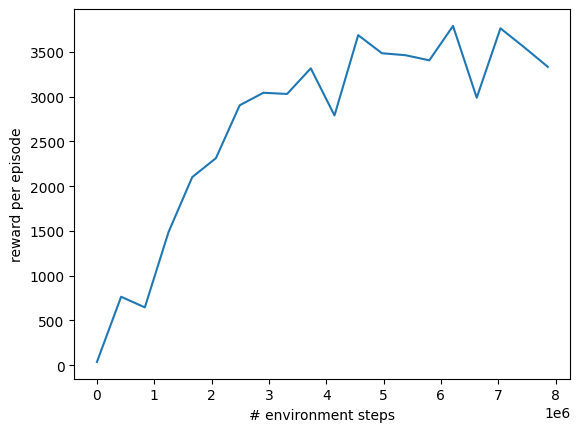

Time to train: 0:06:21.068232


In [ ]:
env_name = 'walker2d'
backend = 'positional'

env = envs.get_environment(env_name=env_name, backend=backend)
state = jax.jit(env.reset)(rng=jax.random.PRNGKey(seed=0))

def train_walker():
    """Train Walker2D with SAC."""
    train_fn = functools.partial(sac.train, num_timesteps=7_864_320, num_evals=20, reward_scaling=5, 
                                 episode_length=1000, normalize_observations=True, action_repeat=1, 
                                 discounting=0.997, learning_rate=6e-4, num_envs=128, batch_size=128, 
                                 grad_updates_per_step=32, max_devices_per_host=1, 
                                 max_replay_size=1048576, min_replay_size=8192, seed=1)
    
 
    
    make_inference_fn, params, _ = train_fn(environment=env, progress_fn=progress)
    print(f'Time to train: {times[-1] - times[0]}')
    return make_inference_fn, params



# 训练保存模型

inference_fn, params = train_walker()



model_path = 'trained_params.pkl'
model.save_params(model_path, params)


In [ ]:
# Save and reload params.
model_path = '/u20/li3658/rl_training/models/test4'
model.save_params(model_path, params)
params = model.load_params(model_path)

inference_fn = inference_fn(params)
jit_inference_fn = jax.jit(inference_fn)

In [ ]:
# eval_env = envs.get_environment(env_name)

# jit_reset = jax.jit(eval_env.reset)
# jit_step = jax.jit(eval_env.step)

In [ ]:
#@title Visualizing a trajectory of the learned inference function

# create an env with auto-reset
env = envs.create(env_name=env_name, backend=backend)

jit_env_reset = jax.jit(env.reset)
jit_env_step = jax.jit(env.step)
jit_inference_fn = jax.jit(inference_fn)

rollout = []
rng = jax.random.PRNGKey(seed=1)
state = jit_env_reset(rng=rng)
for _ in range(1000):
  rollout.append(state.pipeline_state)
  act_rng, rng = jax.random.split(rng)
  act, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_env_step(state, act)

html_output = html.render(env.sys.tree_replace({'opt.timestep': env.dt}), rollout)
with open("output_test_4.html", "w") as f:
    f.write(html_output)
print("Saved visualization as output.html. Open it in a browser.")

# Load RL

In [7]:
#@title Load Model and Define Inference Function
from brax.training.acme import running_statistics
from brax.training.agents.sac import networks as sac_networks
env_name = 'walker2d'
backend = 'positional'
# create an env with auto-reset
env = envs.create(env_name=env_name, backend=backend)
# normalize_fn = lambda x, y: x

model_path = '/u20/li3658/rl_training/models/test4'
params = model.load_params(model_path)
# sac_network = sac_networks.make_sac_networks(
#         env.observation_size, env.action_size, normalize_fn
#     )
sac_network = sac_networks.make_sac_networks(
        action_size=env.action_size, observation_size=env.observation_size, preprocess_observations_fn=running_statistics.normalize
    )
inference = sac_networks.make_inference_fn(sac_network)
jit_inference_fn = inference(params)

jit_inference_fn = jax.jit(jit_inference_fn)

# load gnn model

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, ReduceLROnPlateau
import time
import os
from torch_geometric.nn import GCNConv, GATConv
from torch_geometric.data import Data, Batch

In [9]:
class SimpleWalkerGCN(nn.Module):
    """简化的图卷积网络(GCN)模型"""
    def __init__(self, input_dim=1, hidden_dim=16, output_dim=3):
        super(SimpleWalkerGCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, output_dim)
        
        # 权重初始化
        self._initialize_weights()
        
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        # 应用GCN层
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        
        # 每个图在batch中的索引
        batch_idx = data.batch if hasattr(data, 'batch') else None
        
        # 如果是批处理，需要为每个图处理对应节点
        if batch_idx is not None:
            batch_size = batch_idx.max().item() + 1
            outputs = []
            
            for i in range(batch_size):
                # 计算当前图的节点索引基准
                base_idx = i * 6  # 每个图有6个节点
                # 获取右腿节点 (基准索引 + 3, 4, 5)
                right_nodes = x[base_idx + 3:base_idx + 6]
                
                # 改变这里：取平均而不是连接
                combined = torch.mean(right_nodes, dim=0).unsqueeze(0)
                
                # 应用输出层
                out = self.out(combined)
                outputs.append(out)
            
            # 堆叠所有输出
            return torch.cat(outputs, dim=0)
        else:
            # 单个图处理
            right_nodes = x[3:6]
            combined = torch.mean(right_nodes, dim=0).unsqueeze(0)
            return self.out(combined)

In [10]:
class WalkerGraphBuilder:
    def __init__(self):
        """
        初始化图结构生成器，定义人体腿部关节的连接关系
        """
        # 定义图的结构 - 假设我们有6个节点（左右腿各3个关节）
        self.num_nodes = 6
        
        # 定义边连接 - 按照人体骨骼结构
        self.edge_index_src = [
            0, 1,  # 左腿：大腿→小腿，小腿→脚
            3, 4,  # 右腿：大腿→小腿，小腿→脚
            0, 3,  # 左右腿大腿之间的关系
            1, 4,  # 左右腿小腿之间的关系
            2, 5   # 左右腿脚之间的关系wlak
        ]
        
        # 目标节点
        self.edge_index_dst = [
            1, 2,  # 左腿连接
            4, 5,  # 右腿连接
            3, 0,  # 左右腿大腿连接（双向）
            4, 1,  # 左右腿小腿连接（双向）
            5, 2   # 左右腿脚连接（双向）
        ]
        
        # 转换为PyTorch张量
        self.edge_index = torch.tensor([self.edge_index_src, self.edge_index_dst], 
                                      dtype=torch.long)
    
    def build_graph_from_leg_data(self, left_leg, right_leg):
        """
        将左右腿数据构建为图
        
        参数:
        - left_leg: 左腿3个关节的数据
        - right_leg: 右腿3个关节的数据
        
        返回:
        - torch_geometric.data.Data 对象
        """
        # 确保输入是正确的格式
        if isinstance(left_leg, torch.Tensor):
            left_leg = left_leg.detach().cpu().numpy()
        if isinstance(right_leg, torch.Tensor):
            right_leg = right_leg.detach().cpu().numpy()
            
        # 组合所有节点特征 - 每个节点一个特征维度
        x = torch.cat([
            torch.tensor(left_leg, dtype=torch.float32).view(-1, 1),  # 左腿节点
            torch.tensor(right_leg, dtype=torch.float32).view(-1, 1)  # 右腿节点
        ], dim=0)
        
        # 创建图数据对象
        graph = Data(x=x, edge_index=self.edge_index)
        
        return graph
    
    def build_batch_graphs(self, left_legs, right_legs, device=None):
        """
        批量构建图并合并为一个批次
        
        参数:
        - left_legs: 批量左腿数据 [batch_size, 3]
        - right_legs: 批量右腿数据 [batch_size, 3]
        - device: 设备 (CPU/GPU)
        
        返回:
        - batched_graphs: 批处理后的图数据
        - stacked_targets: 批量右腿标签数据
        """
        batch_size = left_legs.size(0)
        graphs = []
        targets = []
        
        for i in range(batch_size):
            left_leg = left_legs[i]
            right_leg = right_legs[i]
            
            # 构建单个图
            graph = self.build_graph_from_leg_data(left_leg, right_leg)
            graphs.append(graph)
            
            # 保存目标（右腿数据作为标签）
            targets.append(right_leg)
        
        # 合并为批次图
        batched_graphs = Batch.from_data_list(graphs)
        stacked_targets = torch.stack(targets)
        
        # 移动到指定设备
        if device is not None:
            batched_graphs = batched_graphs.to(device)
            stacked_targets = stacked_targets.to(device)
        
        return batched_graphs, stacked_targets


In [11]:
def gnn_inference(model, left_leg_data, graph_builder, device=None, right_leg_dummy=None):
    """
    使用训练好的GNN模型进行推理
    
    参数:
    - model: 训练好的GNN模型
    - left_leg_data: 左腿数据 (3,)
    - graph_builder: 图构建器
    - device: 设备 (CPU/GPU)
    - right_leg_dummy: 占位符，用于构建图 (可选)
    
    返回:
    - 预测的右腿数据 (3,)
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model.to(device)
    model.eval()
    
    # 确保输入格式正确
    if isinstance(left_leg_data, np.ndarray):
        left_leg_tensor = torch.tensor(left_leg_data, dtype=torch.float32)
    elif isinstance(left_leg_data, torch.Tensor):
        left_leg_tensor = left_leg_data
    else:
        raise TypeError("输入数据类型必须是NumPy数组或PyTorch张量")
    
    # 为构建图，我们需要一个右腿占位符
    if right_leg_dummy is None:
        right_leg_dummy = np.zeros_like(left_leg_tensor.detach().cpu().numpy())
    
    # 构建图
    graph = graph_builder.build_graph_from_leg_data(left_leg_tensor, right_leg_dummy)
    graph = graph.to(device)
    
    # 推理
    with torch.no_grad():
        output = model(graph)
            
    return output.cpu().numpy()

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
save_dir="walker_gnn_results"
checkpoint = torch.load(os.path.join(save_dir, 'best_model.pth'))
gnn_model = SimpleWalkerGCN(input_dim=1, hidden_dim=16, output_dim=3).to(device)
gnn_model.load_state_dict(checkpoint['model_state_dict'])
graph_builder = WalkerGraphBuilder()
gnn_model.eval()

SimpleWalkerGCN(
  (conv1): GCNConv(1, 16)
  (conv2): GCNConv(16, 16)
  (out): Linear(in_features=16, out_features=3, bias=True)
)

# Inference part

In [20]:
#@title Visualizing a trajectory of the learned inference function
import jax
import jax.numpy as jnp
# create an env with auto-reset

env_name = 'walker2d'
backend = 'positional'
env = envs.create(env_name=env_name, backend=backend)

jit_env_reset = jax.jit(env.reset)
jit_env_step = jax.jit(env.step)
# jit_inference_fn = jax.jit(inference_fn)
data = []
rollout = []
rng = jax.random.PRNGKey(seed=1)
gnn_model.to(device)
gnn_model.eval()
state = jit_env_reset(rng=rng)
for _ in range(1000):
    rollout.append(state.pipeline_state)
    act_rng, rng = jax.random.split(rng)
    act, _ = jit_inference_fn(state.obs, act_rng)
    state = jit_env_step(state, act)
    
    # left_leg_data = act[jnp.array(left_leg_indices)]
    left_leg_data = act[:3]

    # 添加批次维度以防BatchNorm问题
    left_leg_tensor = torch.tensor(np.array(left_leg_data).copy(), dtype=torch.float32).unsqueeze(0).to(device)

    # right_leg_tensor = gnn_model(left_leg_tensor) 
    right_leg = gnn_inference(gnn_model, left_leg_tensor, graph_builder)
    
    # 确保形状正确
    action = np.concatenate([
        left_leg_tensor.cpu().detach().numpy().squeeze(), 
        # right_leg_tensor.cpu().detach().numpy().squeeze()
        np.array(right_leg).squeeze()

    ])  
    
    # 使用元组而不是列表，并移除多余维度
    data.append((
        left_leg_tensor.cpu().detach().numpy().squeeze(), 
        # right_leg_tensor.cpu().detach().numpy().squeeze()
        np.array(right_leg).squeeze()
    ))
    
    state = jax.jit(env.step)(state, jnp.array(action))
    rollout.append(state.pipeline_state)

print("data:", data[0])  # 只打印第一个样本查看格式

html_output = html.render(env.sys.tree_replace({'opt.timestep': env.dt}), rollout)
with open("output_test_16.html", "w") as f:
    f.write(html_output)
print("Saved visualization as output.html. Open it in a browser.")

data: (array([-0.888,  0.243,  0.985], dtype=float32), array([-0.035,  0.293,  0.197], dtype=float32))
Saved visualization as output.html. Open it in a browser.


# Customize Env

In [6]:
from brax.envs.base import Env, State
import jax.numpy as jp

class WalkerGNNWrapper(Env):
    """只接收左腿动作(3维)，用GNN生成右腿动作后再丢给 base_env.step"""

    def __init__(self, base_env: Env, gnn_inference_fn):
        self._base_env = base_env
        self._gnn_inference_fn = gnn_inference_fn

    # =========== 1) 必须显式地覆写抽象属性 ===========

    @property
    def action_size(self) -> int:
        # 让 SAC 只输出3维动作，对应"左腿"
        return 3

    @property
    def observation_size(self) -> int:
        # 如果观测不变，就返回原环境的 observation_size
        return self._base_env.observation_size

    @property
    def backend(self) -> str:
        # 通常复用原环境的 backend，比如 'positional', 'spring', 'mjx' 等
        return self._base_env.backend

    # =========== 2) 重写 reset 和 step ===========
    
    def reset(self, rng: jp.ndarray) -> State:
        """直接调用原环境的 reset"""
        return self._base_env.reset(rng)

    def step(self, state: State, left_leg_action: jp.ndarray) -> State:
        """用GNN生成右腿动作，并拼接后交给 base_env.step"""
        # 1) 基于 obs 用 GNN 推断右腿动作(3维)
        left_leg_tensor = torch.tensor(np.array(left_leg_action).copy(), dtype=torch.float32).unsqueeze(0).to(device)
        right_leg_action = self._gnn_inference_fn(gnn_model, left_leg_tensor, graph_builder)
        # 2) 拼接成完整动作(假设 walker2d: 前3=左腿, 后3=右腿)
        full_action = jp.concatenate([left_leg_action,  np.array(right_leg_action).squeeze()])
        # 3) 调用 base_env 原始逻辑
        new_state = self._base_env.step(state, full_action)
        return new_state


# Training without gnn

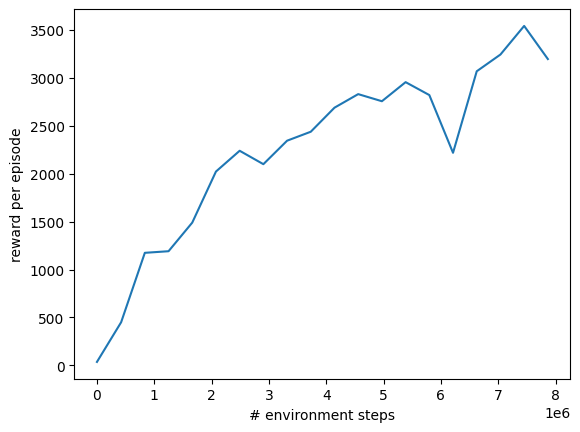

Time to train: 0:52:39.868527


In [29]:
env_name = 'walker2d'
backend = 'positional'

env = envs.get_environment(env_name=env_name, backend=backend)
state = jax.jit(env.reset)(rng=jax.random.PRNGKey(seed=0))

def train_walker():
    """Train Walker2D with SAC."""
    train_fn = functools.partial(sac.train, num_timesteps=7_864_320, num_evals=20, reward_scaling=5, 
                                 episode_length=1000, normalize_observations=True, action_repeat=1, 
                                 discounting=0.997, learning_rate=6e-4, num_envs=128, batch_size=128, 
                                 grad_updates_per_step=32, max_devices_per_host=1, 
                                 max_replay_size=1048576, min_replay_size=8192, seed=1)
    
 
    
    make_inference_fn, params, _ = train_fn(environment=env, progress_fn=progress)
    print(f'Time to train: {times[-1] - times[0]}')
    return make_inference_fn, params



# 训练保存模型

inference_fn, params = train_walker()



# model_path = 'trained_params.pkl'
# model.save_params(model_path, params)


In [ ]:
#@title Visualizing a trajectory of the learned inference function

# create an env with auto-reset
env = envs.create(env_name=env_name, backend=backend)

jit_env_reset = jax.jit(env.reset)
jit_env_step = jax.jit(env.step)
jit_inference_fn = jax.jit(inference_fn)

rollout = []
rng = jax.random.PRNGKey(seed=1)
state = jit_env_reset(rng=rng)
for _ in range(1000):
  rollout.append(state.pipeline_state)
  act_rng, rng = jax.random.split(rng)
  act, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_env_step(state, act)

html_output = html.render(env.sys.tree_replace({'opt.timestep': env.dt}), rollout)
with open("output_test_17.html", "w") as f:
    f.write(html_output)
print("Saved visualization as output.html. Open it in a browser.")

# Training with GNN

# TESTING on regular GNN


In [6]:
import jax
import jax.numpy as jnp
import flax.linen as nn
from typing import Tuple, List, Callable, Any, Optional
import numpy as np

# 用于替代PyTorch Geometric的GCNConv层的JAX/Flax实现
class GCNConvBrax(nn.Module):
    """JAX/Flax实现的图卷积层"""
    features: int
    
    @nn.compact
    def __call__(self, x, edge_index):
        # 初始化权重
        weight = self.param('weight', 
                           nn.initializers.variance_scaling(2.0, 'fan_out', 'normal'), 
                           (x.shape[-1], self.features))
        
        # 构建邻接矩阵
        n = x.shape[0]
        adj = jnp.zeros((n, n))
        
        # 填充邻接矩阵
        def fill_adj(adj, edges):
            src, dst = edges[0], edges[1]
            return adj.at[src, dst].set(1.0)
        
        adj = fill_adj(adj, edge_index)
        
        # 计算度矩阵的逆平方根
        degrees = jnp.sum(adj, axis=1)
        d_inv_sqrt = jnp.power(degrees + 1e-6, -0.5)
        d_inv_sqrt = jnp.where(jnp.isinf(d_inv_sqrt), 0., d_inv_sqrt)
        
        # 归一化邻接矩阵
        d_matrix = jnp.diag(d_inv_sqrt)
        norm_adj = d_matrix @ adj @ d_matrix
        
        # 信息传递
        support = x @ weight  # XW
        output = norm_adj @ support  # Â·XW
        
        return output

class SimpleWalkerGCNBrax(nn.Module):
    """Brax/JAX版本的简化图卷积网络(GCN)模型"""
    input_dim: int = 1
    hidden_dim: int = 16
    output_dim: int = 3
    
    def setup(self):
        self.conv1 = GCNConvBrax(features=self.hidden_dim)
        self.conv2 = GCNConvBrax(features=self.hidden_dim)
        self.out = nn.Dense(features=self.output_dim, 
                           kernel_init=nn.initializers.variance_scaling(2.0, 'fan_out', 'normal'),
                           bias_init=nn.initializers.zeros)
    
    def __call__(self, data, batch_size=None):
        x, edge_index = data['x'], data['edge_index']
        
        # 应用GCN层
        x = nn.relu(self.conv1(x, edge_index))
        x = nn.relu(self.conv2(x, edge_index))
        
        # 处理batch
        batch_idx = data.get('batch', None)
        
        if batch_idx is not None and batch_size is not None:
            # 使用传入的batch_size而不是从数据中计算
            outputs = []
            
            # 对每个图分别处理
            for i in range(batch_size):
                # 计算当前图的节点索引基准
                base_idx = i * 6  # 每个图有6个节点
                
                # 只使用左腿节点进行预测 (基准索引 + 0, 1, 2)
                left_nodes = x[base_idx:base_idx + 3]
                
                # 取平均
                combined = jnp.mean(left_nodes, axis=0)
                combined = combined.reshape(1, -1)  # 确保形状正确
                
                # 应用输出层预测右腿动作
                out = self.out(combined)
                outputs.append(out)
            
            # 使用静态连接代替动态连接
            return jnp.concatenate(jnp.array(outputs), axis=0)
        else:
            # 单个图处理
            left_nodes = x[0:3]  # 使用左腿节点 (索引 0, 1, 2)
            combined = jnp.mean(left_nodes, axis=0).reshape(1, -1)
            return self.out(combined)  # 预测右腿动作

# 用于导入PyTorch模型参数的辅助函数
def load_pytorch_weights(flax_model, pytorch_state_dict):
    """
    将PyTorch模型参数导入到Flax模型
    
    Args:
        flax_model: 初始化的Flax模型
        pytorch_state_dict: PyTorch模型的state_dict
    
    Returns:
        params: 更新后的Flax模型参数
    """
    import torch  # 仅在这个函数中导入torch
    
    # 获取Flax模型的默认参数
    params = flax_model.init(jax.random.PRNGKey(0), 
                            {'x': jnp.ones((6, 1)), 
                             'edge_index': jnp.zeros((2, 10), dtype=jnp.int32)})
    
    # 映射PyTorch参数到Flax参数
    param_mapping = {
        'conv1.weight': ('params', 'conv1', 'weight'),
        'conv2.weight': ('params', 'conv2', 'weight'),
        'out.weight': ('params', 'out', 'kernel'),
        'out.bias': ('params', 'out', 'bias')
    }
    
    # 更新Flax参数
    for pt_name, flax_path in param_mapping.items():
        if pt_name in pytorch_state_dict:
            pt_param = pytorch_state_dict[pt_name].detach().numpy()
            
            # 处理特殊情况
            if 'kernel' in flax_path:  # 线性层权重转置
                pt_param = pt_param.T
            
            # 使用嵌套访问更新params字典
            current = params
            for i, key in enumerate(flax_path):
                if i == len(flax_path) - 1:
                    current[key] = pt_param
                else:
                    current = current[key]
    
    return params

# 使用示例
def create_brax_model_from_pytorch(pytorch_state_dict_path):
    """
    从PyTorch模型创建Brax模型
    
    Args:
        pytorch_state_dict_path: PyTorch模型state_dict的路径
    
    Returns:
        model: Brax模型
        params: 导入的参数
    """
    import torch
    
    # 加载PyTorch模型参数
    pt_state_dict = torch.load(pytorch_state_dict_path)
    
    # 创建Brax模型
    brax_model = SimpleWalkerGCNBrax(input_dim=1, hidden_dim=16, output_dim=3)
    
    # 导入参数
    params = load_pytorch_weights(brax_model, pt_state_dict)
    
    return brax_model, params

In [7]:
import jax
import jax.numpy as jnp
import numpy as np
from typing import Tuple, List, Dict, Any, Optional

class WalkerGraphBuilderBrax:
    def __init__(self):
        """
        初始化图结构生成器，定义人体腿部关节的连接关系（Brax/JAX版本）
        """
        # 定义图的结构 - 假设我们有6个节点（左右腿各3个关节）
        self.num_nodes = 6
        
        # 定义边连接 - 按照人体骨骼结构
        self.edge_index_src = [
            0, 1,  # 左腿：大腿→小腿，小腿→脚
            3, 4,  # 右腿：大腿→小腿，小腿→脚
            0, 3,  # 左右腿大腿之间的关系
            1, 4,  # 左右腿小腿之间的关系
            2, 5   # 左右腿脚之间的关系
        ]
        
        # 目标节点
        self.edge_index_dst = [
            1, 2,  # 左腿连接
            4, 5,  # 右腿连接
            3, 0,  # 左右腿大腿连接（双向）
            4, 1,  # 左右腿小腿连接（双向）
            5, 2   # 左右腿脚连接（双向）
        ]
        
        # 转换为JAX数组
        self.edge_index = jnp.array([self.edge_index_src, self.edge_index_dst], 
                                  dtype=jnp.int32)
    
    def build_graph_from_leg_data(self, left_leg, right_leg):
        """
        将左右腿数据构建为图
        
        参数:
        - left_leg: 左腿3个关节的数据
        - right_leg: 右腿3个关节的数据
        
        返回:
        - 包含图数据的字典
        """
        # 转换输入为JAX数组（如果需要）
        if not isinstance(left_leg, jnp.ndarray):
            left_leg = jnp.array(left_leg, dtype=jnp.float32)
        if not isinstance(right_leg, jnp.ndarray):
            right_leg = jnp.array(right_leg, dtype=jnp.float32)
            
        # 组合所有节点特征 - 每个节点一个特征维度
        left_leg_reshaped = left_leg.reshape(-1, 1)  # 左腿节点
        right_leg_reshaped = right_leg.reshape(-1, 1)  # 右腿节点
        x = jnp.concatenate([left_leg_reshaped, right_leg_reshaped], axis=0)
        
        # 创建图数据字典（替代PyTorch Geometric的Data对象）
        graph = {
            'x': x, 
            'edge_index': self.edge_index
        }
        
        return graph
    
    def build_batch_graphs(self, left_legs, right_legs):
        """
        批量构建图并合并为一个批次
        
        参数:
        - left_legs: 批量左腿数据 [batch_size, 3]
        - right_legs: 批量右腿数据 [batch_size, 3]
        
        返回:
        - batched_graph: 批处理后的图数据
        - stacked_targets: 批量右腿标签数据
        """
        # 转换输入为JAX数组（如果需要）
        if not isinstance(left_legs, jnp.ndarray):
            left_legs = jnp.array(left_legs, dtype=jnp.float32)
        if not isinstance(right_legs, jnp.ndarray):
            right_legs = jnp.array(right_legs, dtype=jnp.float32)
        
        batch_size = left_legs.shape[0]
        
        # 预分配存储空间
        all_x = []
        all_edges = []
        all_batch_indices = []
        
        # 为每个样本构建图
        for i in range(batch_size):
            # 获取当前样本的腿部数据
            left_leg = left_legs[i]
            right_leg = right_legs[i]
            
            # 组合节点特征
            left_leg_reshaped = left_leg.reshape(-1, 1)
            right_leg_reshaped = right_leg.reshape(-1, 1)
            x = jnp.concatenate([left_leg_reshaped, right_leg_reshaped], axis=0)
            all_x.append(x)
            
            # 计算边索引的偏移
            offset = i * self.num_nodes
            edge_offset = self.edge_index + offset
            all_edges.append(edge_offset)
            
            # 记录批次索引
            batch_index = jnp.ones(self.num_nodes, dtype=jnp.int32) * i
            all_batch_indices.append(batch_index)
        
        # 合并数据
        batched_x = jnp.concatenate(all_x, axis=0)
        batched_edge_index = jnp.concatenate(all_edges, axis=1)
        batched_batch = jnp.concatenate(all_batch_indices, axis=0)
        
        # 创建批处理图
        batched_graph = {
            'x': batched_x,
            'edge_index': batched_edge_index,
            'batch': batched_batch
        }
        
        return batched_graph, right_legs
    
    @staticmethod
    def convert_pytorch_batch_to_brax(pytorch_batch, targets=None):
        """
        将PyTorch Geometric的Batch对象转换为Brax兼容的格式
        
        参数:
        - pytorch_batch: PyTorch Geometric的Batch对象
        - targets: 可选的目标数据
        
        返回:
        - brax_batch: Brax兼容的批处理图数据
        - targets_jax: JAX格式的目标数据
        """
        import torch  # 仅在这个函数中导入torch
        
        # 转换x
        x_np = pytorch_batch.x.detach().cpu().numpy()
        x_jax = jnp.array(x_np)
        
        # 转换edge_index
        edge_index_np = pytorch_batch.edge_index.detach().cpu().numpy()
        edge_index_jax = jnp.array(edge_index_np, dtype=jnp.int32)
        
        # 转换batch
        if hasattr(pytorch_batch, 'batch'):
            batch_np = pytorch_batch.batch.detach().cpu().numpy()
            batch_jax = jnp.array(batch_np, dtype=jnp.int32)
        else:
            # 如果没有batch属性，创建一个默认的（所有节点都属于同一个图）
            batch_jax = jnp.zeros(x_jax.shape[0], dtype=jnp.int32)
        
        # 构建Brax兼容的图
        brax_batch = {
            'x': x_jax,
            'edge_index': edge_index_jax,
            'batch': batch_jax
        }
        
        # 转换目标（如果有）
        targets_jax = None
        if targets is not None:
            if isinstance(targets, torch.Tensor):
                targets_np = targets.detach().cpu().numpy()
                targets_jax = jnp.array(targets_np)
        
        return brax_batch, targets_jax

In [8]:
import jax
import jax.numpy as jnp
import os
import torch  # 仅用于加载PyTorch模型

# # 导入我们之前定义的Brax模型和图构建器
# from brax_gnn_model import SimpleWalkerGCNBrax, load_pytorch_weights
# from brax_graph_builder import WalkerGraphBuilderBrax

def load_gnn_model_brax(save_dir="walker_gnn_results", model_filename="best_model.pth"):
    """
    加载训练好的PyTorch GNN模型并转换为Brax版本
    
    Args:
        save_dir: 保存模型的目录
        model_filename: 模型文件名
    
    Returns:
        brax_model: Brax版本的GNN模型
        params: 从PyTorch模型导入的参数
        graph_builder: Brax版本的图构建器
    """
    # 加载PyTorch模型checkpoint
    pytorch_checkpoint = torch.load(
        os.path.join(save_dir, model_filename), 
        map_location=torch.device('cpu')  # 确保在CPU上加载
    )
    
    # 获取模型参数
    pytorch_state_dict = pytorch_checkpoint['model_state_dict']
    
    # 创建Brax模型
    brax_model = SimpleWalkerGCNBrax(input_dim=1, hidden_dim=16, output_dim=3)
    
    # 导入PyTorch参数到Brax模型
    params = load_pytorch_weights(brax_model, pytorch_state_dict)
    
    # 创建Brax版本的图构建器
    graph_builder = WalkerGraphBuilderBrax()
    
    print("成功将PyTorch GNN模型转换为Brax版本")
    
    return brax_model, params, graph_builder

# 单个预测函数
def predict_with_brax_model(model, params, graph_builder, left_leg, right_leg=None):
    """
    使用Brax模型进行预测
    
    Args:
        model: Brax GNN模型
        params: 模型参数
        graph_builder: 图构建器
        left_leg: 左腿数据
        right_leg: 右腿数据（用于构建图，可选）
    
    Returns:
        prediction: 模型预测的右腿动作
    """
    # 将输入数据转换为JAX数组
    if not isinstance(left_leg, jnp.ndarray):
        left_leg = jnp.array(left_leg, dtype=jnp.float32)
    
    # 如果没有提供右腿数据，创建全零数组（仅用于构建图）
    if right_leg is None:
        right_leg = jnp.zeros_like(left_leg)
    elif not isinstance(right_leg, jnp.ndarray):
        right_leg = jnp.array(right_leg, dtype=jnp.float32)
    
    # 构建单个图
    graph = graph_builder.build_graph_from_leg_data(left_leg, right_leg)
    
    # 执行推理
    prediction = model.apply(params, graph)
    
    return prediction

# 批量预测函数
def predict_batch_with_brax_model(model, params, graph_builder, left_legs, right_legs=None):
    """
    使用Brax模型进行批量预测
    
    Args:
        model: Brax GNN模型
        params: 模型参数
        graph_builder: 图构建器
        left_legs: 批量左腿数据 [batch_size, 3]
        right_legs: 批量右腿数据 [batch_size, 3]（用于构建图，可选）
    
    Returns:
        predictions: 批量预测的右腿动作
    """
    # 将输入数据转换为JAX数组
    if not isinstance(left_legs, jnp.ndarray):
        left_legs = jnp.array(left_legs, dtype=jnp.float32)
    
    # 如果没有提供右腿数据，创建全零数组（仅用于构建图）
    if right_legs is None:
        right_legs = jnp.zeros_like(left_legs)
    elif not isinstance(right_legs, jnp.ndarray):
        right_legs = jnp.array(right_legs, dtype=jnp.float32)
    
    # 从输入数据中获取批量大小
    batch_size = left_legs.shape[0]
    
    # 构建批量图
    batched_graph, _ = graph_builder.build_batch_graphs(left_legs, right_legs)
    
    # 执行推理，传入批量大小
    predictions = model.apply(params, batched_graph, batch_size=batch_size)
    
    return predictions

# 使用示例
# if __name__ == "__main__":
 

In [9]:
   # 加载模型
brax_model, params, graph_builder = load_gnn_model_brax()

# 示例输入数据 - 只需要左腿数据即可进行预测
left_leg = jnp.array([0.1, 0.2, 0.3], dtype=jnp.float32)

# 单个预测
prediction = predict_with_brax_model(brax_model, params, graph_builder, left_leg)
print("预测的右腿动作:", prediction)

# 批量预测
batch_size = 4
left_legs = jnp.array([[0.1, 0.2, 0.3], [0.2, 0.3, 0.4], 
                        [0.3, 0.4, 0.5], [0.4, 0.5, 0.6]], dtype=jnp.float32)

batch_predictions = predict_batch_with_brax_model(brax_model, params, graph_builder, left_legs)
print("批量预测的右腿动作:", batch_predictions)

2025-04-06 00:54:30.977220: W external/xla/xla/service/platform_util.cc:211] unable to create StreamExecutor for CUDA:0: : CUDA_ERROR_OUT_OF_MEMORY: out of memory


成功将PyTorch GNN模型转换为Brax版本
预测的右腿动作: [[ 0.587 -0.21  -0.404]]
批量预测的右腿动作: [[ 0.587 -0.21  -0.404]
 [ 0.681 -0.187 -0.451]
 [ 0.776 -0.165 -0.498]
 [ 0.87  -0.143 -0.545]]


In [10]:
from brax.envs.base import Env, State
import jax.numpy as jp

class WalkerGNNWrapper(Env):
    """只接收左腿动作(3维)，用GNN生成右腿动作后再丢给 base_env.step"""

    def __init__(self, base_env: Env, gnn_inference_fn):
        self._base_env = base_env
        self._gnn_inference_fn = gnn_inference_fn

    # =========== 1) 必须显式地覆写抽象属性 ===========

    @property
    def action_size(self) -> int:
        # 让 SAC 只输出3维动作，对应"左腿"
        return 3

    @property
    def observation_size(self) -> int:
        # 如果观测不变，就返回原环境的 observation_size
        return self._base_env.observation_size

    @property
    def backend(self) -> str:
        # 通常复用原环境的 backend，比如 'positional', 'spring', 'mjx' 等
        return self._base_env.backend

    # =========== 2) 重写 reset 和 step ===========
    
    def reset(self, rng: jp.ndarray) -> State:
        """直接调用原环境的 reset"""
        return self._base_env.reset(rng)

    def step(self, state: State, left_leg_action: jp.ndarray) -> State:
        """用GNN生成右腿动作，并拼接后交给 base_env.step"""
        # 1) 基于 obs 用 GNN 推断右腿动作(3维)
        # left_leg_tensor = torch.tensor(np.array(left_leg_action).copy(), dtype=torch.float32).unsqueeze(0).to(device)
        print(f'left_leg dim: {left_leg_action.shape}, {left_leg_action}')

        right_leg_action = self._gnn_inference_fn(brax_model, params, graph_builder, left_leg_action)
        # 2) 拼接成完整动作(假设 walker2d: 前3=左腿, 后3=右腿)
        print(f'left_leg dim: {left_leg_action.shape}, right leg action dim: {right_leg_action.shape}')

        # print(f'left_leg dim: {left_leg_action.shape}, right leg action dim: {right_leg_action.shape}')
        full_action = jp.concatenate([left_leg_action,  jnp.squeeze(right_leg_action)])
        # 3) 调用 base_env 原始逻辑
        new_state = self._base_env.step(state, full_action)
        return new_state


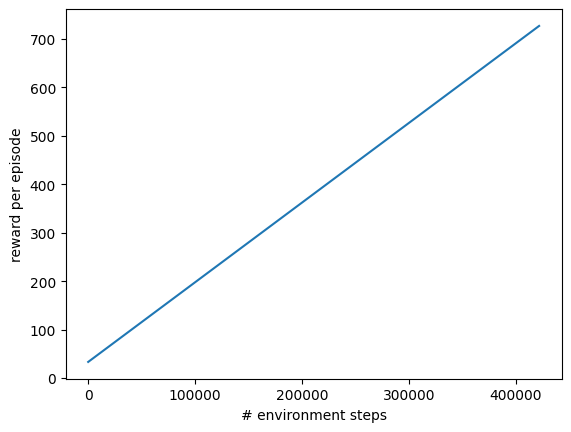

KeyboardInterrupt: 

In [72]:
env_name = 'walker2d'
backend = 'positional'

env = envs.get_environment(env_name=env_name, backend=backend)
wrapped_env = WalkerGNNWrapper(env, predict_with_brax_model)
state = jax.jit(wrapped_env.reset)(rng=jax.random.PRNGKey(seed=0))

def train_walker():
    """Train Walker2D with SAC."""
    train_fn = functools.partial(sac.train, num_timesteps=7_864_320, num_evals=20, reward_scaling=5, 
                                 episode_length=1000, normalize_observations=True, action_repeat=1, 
                                 discounting=0.997, learning_rate=6e-4, num_envs=128, batch_size=128, 
                                 grad_updates_per_step=32, max_devices_per_host=1, 
                                 max_replay_size=1048576, min_replay_size=8192, seed=1)
    
 
    
    make_inference_fn, params_model, _ = train_fn(environment=wrapped_env, progress_fn=progress)
    print(f'Time to train: {times[-1] - times[0]}')
    return make_inference_fn, params_model



# 训练保存模型

inference_fn, params_model = train_walker()



In [21]:
model_path = 'trained_params_test_18.pkl'
model.save_params(model_path, params_model)


In [25]:
# Save and reload params.
model_path = '/u20/li3658/rl_training/trained_params_test_18.pkl'
params_model = model.load_params(model_path)

inference_fn = inference_fn(params_model)
jit_inference_fn = jax.jit(inference_fn)

In [22]:
model_path = '/u20/li3658/rl_training/trained_params_test_18.pkl'
params_model = model.load_params(model_path)
sac_network = sac_networks.make_sac_networks(
        action_size=wrapped_env.action_size, observation_size=wrapped_env.observation_size, preprocess_observations_fn=running_statistics.normalize
    )
inference = sac_networks.make_inference_fn(sac_network)
jit_inference_fn = inference(params_model)

jit_inference_fn = jax.jit(jit_inference_fn)

In [ ]:
#@title Visualizing a trajectory of the learned inference function

# create an env with auto-reset
env = envs.create(env_name=env_name, backend=backend)
# wrapped_env = WalkerGNNWrapper(env, predict_with_brax_model)
jit_env_reset = jax.jit(env.reset)
jit_env_step = jax.jit(env.step)
# jit_inference_fn = jax.jit(inference_fn)

rollout = []
rng = jax.random.PRNGKey(seed=1)
state = jit_env_reset(rng=rng)
for _ in range(1000):
  rollout.append(state.pipeline_state)
  act_rng, rng = jax.random.split(rng)
  left_leg, _ = jit_inference_fn(state.obs, act_rng)

  right_leg = predict_with_brax_model(brax_model, params, graph_builder, left_leg)
  act = jnp.concatenate([left_leg, jnp.squeeze(right_leg)])
  
  state = jit_env_step(state, act)

html_output = html.render(env.sys.tree_replace({'opt.timestep': env.dt}), rollout)
with open("output_test_20.html", "w") as f:
    f.write(html_output)
print("Saved visualization as output.html. Open it in a browser.")

Saved visualization as output.html. Open it in a browser.


: 

# Testing on Temporal GNN

In [6]:
import jax
import jax.numpy as jnp
import flax.linen as nn
from typing import Tuple, List, Dict, Any, Optional

class RGCNConvBrax(nn.Module):
    """JAX/Flax实现的关系型图卷积层 - 更高效的JAX友好设计"""
    features: int
    num_relations: int
    
    @nn.compact
    def __call__(self, x, edge_index, edge_type):
        # 初始化所有关系类型的权重
        all_weights = self.param('weights', 
                               nn.initializers.variance_scaling(2.0, 'fan_out', 'normal'), 
                               (self.num_relations, x.shape[-1], self.features))
        
        n = x.shape[0]
        
        # 为每种关系类型计算转换后的节点特征
        # 即, 对于每种关系 r, 计算 X * W_r
        transformed_features = []
        for r in range(self.num_relations):
            transformed_features.append(x @ all_weights[r])
        
        # 堆叠转换后的特征以供高效访问
        # shape: [num_relations, num_nodes, features]
        stacked_features = jnp.stack(transformed_features)
        
        # 创建结果特征矩阵
        result = jnp.zeros((n, self.features))
        
        # 获取边的源节点、目标节点和关系类型
        src_nodes = edge_index[0]
        dst_nodes = edge_index[1]
        
        # 对于每条边，根据其关系类型聚合消息
        def aggregate_messages(i, acc_result):
            src = src_nodes[i]
            dst = dst_nodes[i]
            rel = edge_type[i]
            
            # 获取源节点的转换特征
            src_feat = stacked_features[rel, src]
            
            # 更新目标节点
            # 注意：在实际情况中，我们可能需要使用更复杂的归一化
            new_result = acc_result.at[dst].add(src_feat)
            
            return new_result
        
        # 使用fori_loop聚合所有边的消息
        aggregated_features = jax.lax.fori_loop(
            0, edge_index.shape[1], aggregate_messages, result
        )
        
        return aggregated_features
class TimeAttention(nn.Module):
    """时间注意力机制"""
    hidden_dim: int
    
    @nn.compact
    def __call__(self, x):
        # x形状: [sequence_length, hidden_dim]
        h1 = nn.Dense(self.hidden_dim)(x)
        h1 = nn.relu(h1)
        scores = nn.Dense(1)(h1)  # [sequence_length, 1]
        
        # Softmax归一化
        weights = jax.nn.softmax(scores, axis=0)  # [sequence_length, 1]
        return weights

class TemporalWalkerGNNBrax(nn.Module):
    """Brax版本的时序图神经网络模型"""
    input_dim: int = 1
    hidden_dim: int = 16
    output_dim: int = 3
    num_nodes: int = 6
    sequence_length: int = 5
    num_relations: int = 2
    num_layers: int = 2
    
    def setup(self):
        # 关系型GCN层
        self.rgcn1 = RGCNConvBrax(features=self.hidden_dim, num_relations=self.num_relations)
        
        # 多层RGCN
        self.rgcn_layers = [
            RGCNConvBrax(features=self.hidden_dim, num_relations=self.num_relations)
            for _ in range(self.num_layers - 1)
        ]
        
        # 时间注意力机制
        self.time_attention = TimeAttention(hidden_dim=self.hidden_dim)
        
        # 输出层
        self.out = nn.Dense(features=self.output_dim,
                           kernel_init=nn.initializers.variance_scaling(2.0, 'fan_out', 'normal'),
                           bias_init=nn.initializers.zeros)
    
    def __call__(self, data, batch_size=None):
        x, edge_index, edge_type = data['x'], data['edge_index'], data['edge_type']
        batch = data.get('batch', None)
        
        # 应用关系型GCN层
        x = nn.relu(self.rgcn1(x, edge_index, edge_type))
        
        # 应用额外的RGCN层
        for layer in self.rgcn_layers:
            x = nn.relu(layer(x, edge_index, edge_type))
        
        # 处理批处理数据
        if batch is not None and batch_size is not None:
            results = []
            
            # 对每个样本在批次中单独处理
            for i in range(batch_size):
                # 找出当前批次样本的所有节点
                mask = batch == i
                batch_nodes = x[mask]
                
                # 确保节点数量正确
                total_expected_nodes = self.sequence_length * self.num_nodes
                batch_nodes = batch_nodes[:total_expected_nodes]  # 截断多余节点
                
                # 如果节点不足，则填充
                if batch_nodes.shape[0] < total_expected_nodes:
                    pad_size = total_expected_nodes - batch_nodes.shape[0]
                    padding = jnp.zeros((pad_size, x.shape[1]))
                    batch_nodes = jnp.concatenate([batch_nodes, padding], axis=0)
                
                # 重塑为 [sequence_length, num_nodes, hidden_dim]
                batch_nodes_reshaped = batch_nodes.reshape(self.sequence_length, self.num_nodes, -1)
                
                # 计算每个时间步的平均表示
                time_mean = jnp.mean(batch_nodes_reshaped, axis=1)  # [sequence_length, hidden_dim]
                
                # 应用时间注意力
                time_weights = self.time_attention(time_mean)  # [sequence_length, 1]
                
                # 加权聚合所有时间步
                time_weights_expanded = time_weights[:, None, :]  # [sequence_length, 1, 1]
                weighted_batch = batch_nodes_reshaped * time_weights_expanded  # 使用广播
                weighted_representation = jnp.sum(weighted_batch, axis=0)  # [num_nodes, hidden_dim]
                
                # 获取右腿节点（节点3，4，5）
                right_leg_representation = weighted_representation[3:6]  # [3, hidden_dim]
                
                # 聚合右腿节点特征
                aggregated_right_leg = jnp.mean(right_leg_representation, axis=0)  # [hidden_dim]
                
                # 应用输出层
                out = self.out(aggregated_right_leg)
                results.append(out)
            
            # 堆叠所有输出
            return jnp.stack(results)
        else:
            # 单个样本处理
            # 重塑为 [sequence_length, num_nodes, hidden_dim]
            total_nodes = self.sequence_length * self.num_nodes
            x_reshaped = x[:total_nodes].reshape(self.sequence_length, self.num_nodes, -1)
            
            # 计算每个时间步的平均表示
            time_mean = jnp.mean(x_reshaped, axis=1)  # [sequence_length, hidden_dim]
            
            # 应用时间注意力
            time_weights = self.time_attention(time_mean)  # [sequence_length, 1]
            
            # 加权聚合所有时间步
            time_weights_expanded = time_weights[:, None, :]  # [sequence_length, 1, 1]
            weighted_batch = x_reshaped * time_weights_expanded  # 使用广播
            weighted_representation = jnp.sum(weighted_batch, axis=0)  # [num_nodes, hidden_dim]
            
            # 获取右腿节点（节点3，4，5）
            right_leg_representation = weighted_representation[3:6]  # [3, hidden_dim]
            
            # 聚合右腿节点特征
            aggregated_right_leg = jnp.mean(right_leg_representation, axis=0)  # [hidden_dim]
            
            # 应用输出层并返回
            return self.out(aggregated_right_leg)[None, :]  # 添加批量维度 [1, output_dim]

# 用于导入PyTorch模型参数的辅助函数
def load_pytorch_temporal_weights(flax_model, pytorch_state_dict):
    """
    将PyTorch时序GNN模型参数导入到Flax模型
    
    Args:
        flax_model: 初始化的Flax时序GNN模型
        pytorch_state_dict: PyTorch模型的state_dict
    
    Returns:
        params: 更新后的Flax模型参数
    """
    # 获取Flax模型的默认参数
    key = jax.random.PRNGKey(0)
    dummy_x = jnp.ones((30, 1))  # 假设5个时间步，每步6个节点，每个节点1维特征
    dummy_edge_index = jnp.zeros((2, 20), dtype=jnp.int32)
    dummy_edge_type = jnp.zeros(20, dtype=jnp.int32)
    dummy_data = {
        'x': dummy_x,
        'edge_index': dummy_edge_index,
        'edge_type': dummy_edge_type
    }
    
    params = flax_model.init(key, dummy_data)
    
    # 映射PyTorch参数到Flax参数
    # 这里需要根据实际模型结构进行调整
    param_mapping = {
        # RGCN1层的权重映射
        'rgcn1.weight_0': ('params', 'rgcn1', 'weight_0'),
        'rgcn1.weight_1': ('params', 'rgcn1', 'weight_1'),
        
        # RGCN其他层的权重映射 (需要根据层数调整)
        'rgcn_layers.0.weight_0': ('params', 'rgcn_layers_0', 'weight_0'),
        'rgcn_layers.0.weight_1': ('params', 'rgcn_layers_0', 'weight_1'),
        
        # 时间注意力层
        'time_attention.0.weight': ('params', 'time_attention', 'Dense_0', 'kernel'),
        'time_attention.0.bias': ('params', 'time_attention', 'Dense_0', 'bias'),
        'time_attention.2.weight': ('params', 'time_attention', 'Dense_1', 'kernel'),
        'time_attention.2.bias': ('params', 'time_attention', 'Dense_1', 'bias'),
        
        # 输出层
        'out.weight': ('params', 'out', 'kernel'),
        'out.bias': ('params', 'out', 'bias')
    }
    
    # 更新Flax参数
    for pt_name, flax_path in param_mapping.items():
        if pt_name in pytorch_state_dict:
            pt_param = pytorch_state_dict[pt_name].detach().numpy()
            
            # 处理特殊情况
            if 'kernel' in flax_path or 'weight' in flax_path[-1]:
                if len(pt_param.shape) == 2:
                    pt_param = pt_param.T  # 线性层权重需要转置
            
            # 嵌套访问和更新params字典
            current = params
            for i, key in enumerate(flax_path):
                if i == len(flax_path) - 1:
                    current[key] = pt_param
                else:
                    current = current[key]
    
    return params

In [7]:
import jax
import jax.numpy as jnp
import numpy as np
from typing import Tuple, List, Dict, Any, Optional

class TemporalWalkerGraphBuilderBrax:
    def __init__(self, sequence_length=5):
        """
        初始化时序图结构生成器，Brax/JAX版本
        
        Args:
            sequence_length: 时间序列长度
        """
        # 定义图的结构 - 假设我们有6个节点（左右腿各3个关节）
        self.num_nodes = 6
        self.sequence_length = sequence_length
        
        # 定义空间边连接 - 按照人体骨骼结构
        self.spatial_edge_index_src = [
            0, 1,  # 左腿：大腿→小腿，小腿→脚
            3, 4,  # 右腿：大腿→小腿，小腿→脚
            0, 3,  # 左右腿大腿之间的关系
            1, 4,  # 左右腿小腿之间的关系
            2, 5   # 左右腿脚之间的关系
        ]
        
        # 目标节点
        self.spatial_edge_index_dst = [
            1, 2,  # 左腿连接
            4, 5,  # 右腿连接
            3, 0,  # 左右腿大腿连接（双向）
            4, 1,  # 左右腿小腿连接（双向）
            5, 2   # 左右腿脚连接（双向）
        ]
        
        # 转换为JAX数组 - 空间边
        self.spatial_edge_index = jnp.array([self.spatial_edge_index_src, self.spatial_edge_index_dst], 
                                          dtype=jnp.int32)
        
        # 创建时间边 - 连接不同时间步的相同节点
        self._build_temporal_edges()
    
    def _build_temporal_edges(self):
        """构建时间边连接不同时间步的相同节点"""
        temporal_edges_src = []
        temporal_edges_dst = []
        
        # 对于每个时间步t和每个节点，连接到t+1时间步的相同节点
        for t in range(self.sequence_length - 1):
            base_t = t * self.num_nodes  # 当前时间步的基础索引
            base_t_next = (t + 1) * self.num_nodes  # 下一个时间步的基础索引
            
            for node in range(self.num_nodes):
                # t时间步的节点连接到t+1时间步的相同节点
                temporal_edges_src.append(base_t + node)
                temporal_edges_dst.append(base_t_next + node)
        
        # 转换为JAX数组
        self.temporal_edge_index = jnp.array([temporal_edges_src, temporal_edges_dst], 
                                            dtype=jnp.int32)
        
        # 边的类型: 0=空间边, 1=时间边
        self.edge_type = jnp.zeros(len(self.spatial_edge_index_src) + len(temporal_edges_src), 
                                  dtype=jnp.int32)
        self.edge_type = self.edge_type.at[len(self.spatial_edge_index_src):].set(1)
        
        # 组合空间和时间边
        self.combined_edge_index = jnp.concatenate([
            self.spatial_edge_index, 
            self.temporal_edge_index
        ], axis=1)
    
    def build_temporal_graph_from_sequence(self, left_leg_sequence, right_leg_sequence):
        """
        将左右腿的时间序列数据构建为时序图
        
        Args:
            left_leg_sequence: 左腿序列数据 [seq_len, 3]
            right_leg_sequence: 右腿序列数据 [seq_len, 3]
        
        Returns:
            graph: 图数据字典
        """
        # 确保输入是JAX数组
        if not isinstance(left_leg_sequence, jnp.ndarray):
            left_leg_sequence = jnp.array(left_leg_sequence, dtype=jnp.float32)
        if not isinstance(right_leg_sequence, jnp.ndarray):
            right_leg_sequence = jnp.array(right_leg_sequence, dtype=jnp.float32)
            
        # 截断或填充序列以匹配所需的序列长度
        seq_len = min(left_leg_sequence.shape[0], self.sequence_length)
        
        # 准备节点特征
        node_features = []
        
        # 使用seq_len个时间步的数据
        for t in range(seq_len):
            # 获取当前时间步的左右腿数据
            left_leg_t = left_leg_sequence[t]
            right_leg_t = right_leg_sequence[t]
            
            # 添加当前时间步的节点特征 - 每个节点单独处理以确保维度正确
            for i in range(3):  # 左腿3个节点
                node_features.append(left_leg_t[i].reshape(1, 1))
            for i in range(3):  # 右腿3个节点
                node_features.append(right_leg_t[i].reshape(1, 1))
        
        # 如果序列长度小于所需长度，用最后一个时间步的数据填充
        if seq_len < self.sequence_length:
            last_left = left_leg_sequence[seq_len-1]
            last_right = right_leg_sequence[seq_len-1]
            
            for _ in range(self.sequence_length - seq_len):
                for i in range(3):  # 左腿3个节点
                    node_features.append(last_left[i].reshape(1, 1))
                for i in range(3):  # 右腿3个节点
                    node_features.append(last_right[i].reshape(1, 1))
        
        # 合并所有节点特征
        x = jnp.concatenate(node_features, axis=0)
        
        # 创建图数据字典
        graph = {
            'x': x, 
            'edge_index': self.combined_edge_index,
            'edge_type': self.edge_type,
        }
        
        return graph
    
    def build_batch_temporal_graphs(self, left_leg_sequences, right_leg_sequences):
        """
        批量构建时序图并合并为一个批次
        
        Args:
            left_leg_sequences: 批量左腿序列数据 [batch_size, seq_len, 3]
            right_leg_sequences: 批量右腿序列数据 [batch_size, seq_len, 3]
        
        Returns:
            batched_graph: 批处理后的图数据
            targets: 批量右腿标签数据（最后一个时间步）
        """
        # 确保输入是JAX数组
        if not isinstance(left_leg_sequences, jnp.ndarray):
            left_leg_sequences = jnp.array(left_leg_sequences, dtype=jnp.float32)
        if not isinstance(right_leg_sequences, jnp.ndarray):
            right_leg_sequences = jnp.array(right_leg_sequences, dtype=jnp.float32)
        
        batch_size = left_leg_sequences.shape[0]
        
        # 预分配存储数组
        all_x = []
        all_edges = []
        all_edge_types = []
        all_batch_indices = []
        targets = []
        
        # 构建每个样本的图
        for i in range(batch_size):
            left_seq = left_leg_sequences[i]
            right_seq = right_leg_sequences[i]
            
            # 构建单个时序图
            graph = self.build_temporal_graph_from_sequence(left_seq, right_seq)
            
            # 获取节点特征
            x = graph['x']
            all_x.append(x)
            
            # 计算边索引的偏移
            total_nodes = self.sequence_length * self.num_nodes
            offset = i * total_nodes
            
            # 应用偏移到边索引
            edge_index_offset = graph['edge_index'] + offset
            all_edges.append(edge_index_offset)
            
            # 添加边类型
            all_edge_types.append(graph['edge_type'])
            
            # 批次索引
            batch_index = jnp.ones(total_nodes, dtype=jnp.int32) * i
            all_batch_indices.append(batch_index)
            
            # 保存目标（右腿序列最后一个时间步作为标签）
            targets.append(right_seq[-1])
        
        # 合并所有图的数据
        batched_x = jnp.concatenate(all_x, axis=0)
        batched_edge_index = jnp.concatenate(all_edges, axis=1)
        batched_edge_type = jnp.concatenate(all_edge_types, axis=0)
        batched_batch = jnp.concatenate(all_batch_indices, axis=0)
        
        # 创建合并的图数据
        batched_graph = {
            'x': batched_x,
            'edge_index': batched_edge_index,
            'edge_type': batched_edge_type,
            'batch': batched_batch
        }
        
        # 合并目标
        stacked_targets = jnp.stack(targets)
        
        return batched_graph, stacked_targets
    
    @staticmethod
    def convert_pytorch_batch_to_brax(pytorch_batch, targets=None):
        """
        将PyTorch Geometric的Batch对象转换为Brax兼容的格式
        
        Args:
            pytorch_batch: PyTorch Geometric的Batch对象
            targets: 可选的目标数据
        
        Returns:
            brax_batch: Brax兼容的批处理图数据
            targets_jax: JAX格式的目标数据
        """
        import torch  # 仅在这个函数中导入torch
        
        # 转换节点特征
        x_np = pytorch_batch.x.detach().cpu().numpy()
        x_jax = jnp.array(x_np)
        
        # 转换边索引
        edge_index_np = pytorch_batch.edge_index.detach().cpu().numpy()
        edge_index_jax = jnp.array(edge_index_np, dtype=jnp.int32)
        
        # 转换边类型
        edge_type_np = pytorch_batch.edge_type.detach().cpu().numpy()
        edge_type_jax = jnp.array(edge_type_np, dtype=jnp.int32)
        
        # 转换批次索引
        if hasattr(pytorch_batch, 'batch'):
            batch_np = pytorch_batch.batch.detach().cpu().numpy()
            batch_jax = jnp.array(batch_np, dtype=jnp.int32)
        else:
            # 如果没有batch属性，创建一个默认的
            batch_jax = jnp.zeros(x_jax.shape[0], dtype=jnp.int32)
        
        # 创建Brax兼容的图数据
        brax_batch = {
            'x': x_jax,
            'edge_index': edge_index_jax,
            'edge_type': edge_type_jax,
            'batch': batch_jax
        }
        
        # 转换目标（如果有）
        targets_jax = None
        if targets is not None:
            if isinstance(targets, torch.Tensor):
                targets_np = targets.detach().cpu().numpy()
                targets_jax = jnp.array(targets_np)
        
        return brax_batch, targets_jax

In [8]:
import jax
import jax.numpy as jnp
import os
import torch  # 仅用于加载PyTorch模型

# 导入时序GNN相关模块
# from brax_temporal_gnn_model import TemporalWalkerGNNBrax, load_pytorch_temporal_weights
# from brax_temporal_graph_builder import TemporalWalkerGraphBuilderBrax

def load_temporal_gnn_model_brax(save_dir="temporal_walker_gnn_results", model_filename="best_model.pth", sequence_length=5):
    """
    加载训练好的PyTorch时序GNN模型并转换为Brax版本
    
    Args:
        save_dir: 保存模型的目录
        model_filename: 模型文件名
        sequence_length: 序列长度
        
    Returns:
        brax_model: Brax版本的GNN模型
        params: 从PyTorch模型导入的参数
        graph_builder: Brax版本的图构建器
    """
    try:
        # 加载PyTorch模型checkpoint
        pytorch_checkpoint = torch.load(
            os.path.join(save_dir, model_filename), 
            map_location=torch.device('cpu')  # 确保在CPU上加载
        )
        
        # 获取模型参数
        pytorch_state_dict = pytorch_checkpoint['model_state_dict']
    except Exception as e:
        print(f"无法加载PyTorch模型: {e}")
        # 如果无法加载，使用空字典
        pytorch_state_dict = {}
    
    # 创建Brax模型 - 添加所有必要的参数
    brax_model = TemporalWalkerGNNBrax(
        input_dim=1, 
        hidden_dim=16, 
        output_dim=3,
        num_nodes=6,
        sequence_length=sequence_length,
        num_relations=2,
        num_layers=2
    )
    
    # 导入PyTorch参数到Brax模型
    params = load_pytorch_temporal_weights(brax_model, pytorch_state_dict)
    
    # 创建Brax版本的图构建器 - 提供序列长度
    graph_builder = TemporalWalkerGraphBuilderBrax(sequence_length=sequence_length)
    
    print("成功将PyTorch时序GNN模型转换为Brax版本")
    
    return brax_model, params, graph_builder

# 单个预测函数
def predict_with_temporal_gnn(model, params, graph_builder, left_leg_sequence):
    """
    JAX-compatible GNN prediction function
    """
    # Handle batch dimension properly
    batch_mode = left_leg_sequence.ndim > 1
    
    # Ensure data is properly shaped
    if not batch_mode:
        left_leg_sequence = left_leg_sequence.reshape(1, -1)
    
    # Create zero placeholders for right leg (for graph construction only)
    right_leg_sequence = jp.zeros_like(left_leg_sequence)
    
    # Build graph - use jit-compatible operations
    graph = graph_builder.build_temporal_graph_from_sequence(left_leg_sequence, right_leg_sequence)
    
    # Run model - ensure we're returning properly shaped outputs
    prediction = model.apply(params, graph)
    
    return prediction

# 批量预测函数
def predict_batch_with_temporal_gnn(model, params, graph_builder, left_legs_sequences, right_legs_sequences=None):
    """
    使用Brax时序GNN模型进行批量预测
    
    Args:
        model: Brax时序GNN模型
        params: 模型参数
        graph_builder: 图构建器
        left_legs_sequences: 批量左腿时序数据 [batch_size, seq_len, 3]
        right_legs_sequences: 批量右腿时序数据（可选）[batch_size, seq_len, 3]
    
    Returns:
        predictions: 批量预测的右腿动作
    """
    # 将输入数据转换为JAX数组
    if not isinstance(left_legs_sequences, jnp.ndarray):
        left_legs_sequences = jnp.array(left_legs_sequences, dtype=jnp.float32)
    
    # 如果没有提供右腿数据，创建全零数组（仅用于构建图）
    if right_legs_sequences is None:
        right_legs_sequences = jnp.zeros_like(left_legs_sequences)
    elif not isinstance(right_legs_sequences, jnp.ndarray):
        right_legs_sequences = jnp.array(right_legs_sequences, dtype=jnp.float32)
    
    # 从输入数据中获取批量大小
    batch_size = left_legs_sequences.shape[0]
    
    # 构建批量图
    batched_graph, _ = graph_builder.build_batch_temporal_graphs(left_legs_sequences, right_legs_sequences)
    
    # 执行推理，传入批量大小
    predictions = model.apply(params, batched_graph, batch_size=batch_size)
    
    return predictions

# 测试函数
def test_temporal_gnn():
    """测试时序GNN模型的加载和预测"""
    # 加载模型
    brax_model, params, graph_builder = load_temporal_gnn_model_brax()
    
    # 创建示例输入数据 - 时序数据 [seq_len, 3]
    left_leg_sequence = jnp.array(
        [0.1, 0.2, 0.3],
         dtype=jnp.float32)
    
    # 单个预测
    prediction = predict_with_temporal_gnn(brax_model, params, graph_builder, left_leg_sequence)
    print(f"预测结果: {prediction}")
    
    # # 批量预测
    # batch_size = 1
    # left_legs_sequences = jnp.stack([left_leg_sequence] * batch_size)
    # batch_predictions = predict_batch_with_temporal_gnn(brax_model, params, graph_builder, left_legs_sequences)
    # print(f"批量预测结果: {batch_predictions}")
    
    # return brax_model, params, graph_builder

# 使用示例
if __name__ == "__main__":
    test_temporal_gnn()

成功将PyTorch时序GNN模型转换为Brax版本
预测结果: [[-0.37   0.22   0.153]]


In [9]:
   # 加载模型
brax_model, params, graph_builder = load_temporal_gnn_model_brax()

  # 创建示例输入数据 - 时序数据 [seq_len, 3]
left_leg_sequence = jnp.array(
        [[0.1, 0.2, 0.3]], dtype=jnp.float32)

# 单个预测
prediction = predict_with_temporal_gnn(brax_model, params, graph_builder, left_leg_sequence)
print("预测的右腿动作:", prediction)

# 批量预测
batch_size = 4
left_leg_sequence = jnp.array([
        [0.1, 0.2, 0.3],
       
    ], dtype=jnp.float32)
left_legs_sequences = jnp.stack([left_leg_sequence] * batch_size)

batch_predictions = predict_batch_with_temporal_gnn(brax_model, params, graph_builder, left_legs_sequences)
print("批量预测的右腿动作:", batch_predictions)

成功将PyTorch时序GNN模型转换为Brax版本
预测的右腿动作: [[-0.37   0.22   0.153]]
批量预测的右腿动作: [[-0.37   0.22   0.153]
 [-0.37   0.22   0.153]
 [-0.37   0.22   0.153]
 [-0.37   0.22   0.153]]


In [10]:
from brax.envs.base import Env, State
import jax
import jax.numpy as jp

class WalkerGNNWrapper(Env):
    """在特定步数范围内使用GNN预测右腿动作，其他时候使用普通SAC"""

    def __init__(self, base_env: Env, gnn_inference_fn, brax_model, params, graph_builder, 
                 early_start_step=0, early_end_step=0,
                 late_start_step=0, late_end_step=550000):
        self._base_env = base_env
        self._gnn_inference_fn = gnn_inference_fn
        self._brax_model = brax_model
        self._params = params
        self._graph_builder = graph_builder
        
        # 定义两个GNN辅助区间
        self._early_start_step = early_start_step  # 早期GNN辅助开始步数
        self._early_end_step = early_end_step      # 早期GNN辅助结束步数
        self._late_start_step = late_start_step    # 晚期GNN辅助开始步数
        self._late_end_step = late_end_step        # 晚期GNN辅助结束步数

    @property
    def action_size(self) -> int:
        # 保持训练期间动作空间一致性
        return 6  # 始终使用完整的6维动作空间

    @property
    def observation_size(self) -> int:
        return self._base_env.observation_size

    @property
    def backend(self) -> str:
        return self._base_env.backend

    def reset(self, rng: jp.ndarray) -> State:
        base_state = self._base_env.reset(rng)
        # 在state中添加步数计数器
        info = dict(base_state.info)
        info['step_counter'] = jp.zeros((), dtype=jp.int32)
        return base_state.replace(info=info)

    def step(self, state: State, action: jp.ndarray) -> State:
        # 从state中获取步数
        step_counter = state.info.get('step_counter', jp.zeros((), dtype=jp.int32))
        step_counter = step_counter + 1
        
        # 使用GNN预测右腿动作
        def use_gnn(args):
            """使用GNN预测右腿动作"""
            action, _ = args
            # 提取左腿动作（前3维）
            left_leg_action = action[:3]
            # 使用GNN预测右腿动作
            right_leg_action = self._gnn_inference_fn(self._brax_model, self._params, self._graph_builder, left_leg_action)
            right_leg_action = jp.reshape(right_leg_action, left_leg_action.shape)
            # 拼接为完整动作
            full_action = jp.concatenate([left_leg_action, right_leg_action])

            full_action = jax.lax.cond(
            (step_counter >= self._late_start_step) & (step_counter < self._late_end_step),
            lambda _: full_action,
            lambda _: action,
            operand=None  # optional
            )
            # jax.debug.print("GNN mode step: {} full_action: {}",step_counter,full_action)
            return full_action
        
        # 直接使用SAC输出的完整动作
        def use_full_action(args):
            """直接使用完整动作"""
            action, _ = args
            jax.debug.print("SAC mode step: {}",step_counter)
            return action
        full_action = use_gnn((action, state))
        # 判断当前步数是否在早期或晚期GNN辅助范围内
        # is_in_early_gnn_range = (step_counter >= self._early_start_step) & (step_counter < self._early_end_step)
        is_in_late_gnn_range = (step_counter >= self._late_start_step) & (step_counter < self._late_end_step)
        # is_in_gnn_range = is_in_late_gnn_range
        # is_in_gnn_range = jp.any(is_in_gnn_range)  # 将数组转换为标量
        # 使用JAX条件函数选择动作处理方式
        # jax.debug.print("is_in_late_gnn_range {} step: {}", is_in_late_gnn_range, step_counter)
        # full_action = jax.lax.cond(
        #     (step_counter >= self._late_start_step) & (step_counter < self._late_end_step),
        #     use_gnn,
        #     use_full_action,
        #     (action, state)
        #         )
        
        # 执行环境步骤
        new_state = self._base_env.step(state, full_action)
        
        # 更新步数计数器
        info = dict(new_state.info)
        info['step_counter'] = step_counter
        new_state = new_state.replace(info=info)
        
        return new_state

In [11]:
# from datetime import datetime

# xdata, ydata = [], []
# times = [datetime.now()]
# last_mode = None  # 跟踪上一次的模式

# def progress(num_steps, metrics, env_state=None):
#     global last_mode
    
#     times.append(datetime.now())
#     xdata.append(num_steps)
#     ydata.append(metrics['eval/episode_reward'])
    
#     # 计算运行速率
#     elapsed_time = (times[-1] - times[0]).total_seconds()
#     steps_per_second = num_steps / elapsed_time if elapsed_time > 0 else 0
    
#     # 准备输出文本
#     output_lines = [
#         f"Steps: {num_steps:,} | Reward: {metrics['eval/episode_reward']:.2f}",
#         f"Speed: {steps_per_second:.1f} steps/sec | Total time: {elapsed_time:.1f} sec"
#     ]
    
#     # 如果有环境状态，添加模式信息
#     if env_state is not None and hasattr(env_state, 'info') and 'using_gnn' in env_state.info:
#         current_mode = "Hybrid SAC+GNN" if env_state.info['using_gnn'] else "Pure SAC"
#         current_step = env_state.info.get('step_counter', 0)
        
#         # 添加当前模式信息
#         output_lines.append(f"Current Mode: {current_mode} | Internal step: {current_step:,}")
        
#         # 检测模式变化并输出
#         if last_mode is not None and last_mode != current_mode:
#             output_lines.append(f"MODE CHANGED: {last_mode} -> {current_mode}")
        
#         # 更新上一次的模式
#         last_mode = current_mode
    
#     # 打印所有信息
#     print("\n".join(output_lines))
#     print("-" * 50)  # 分隔线

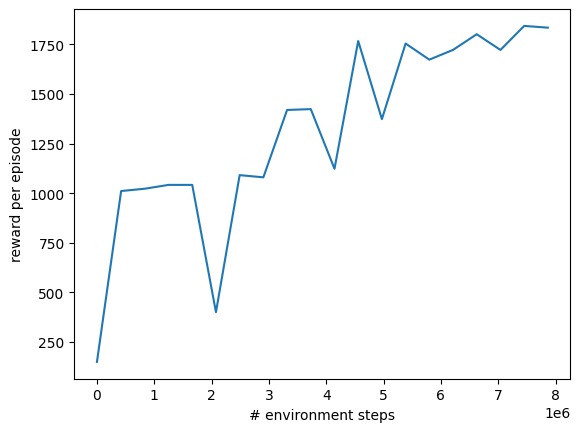

Time to train: 0:06:49.160920


In [12]:
# import jax
# import jax.numpy as jnp
# import functools
# from brax import envs
# from brax.training.agents.sac import train as sac
# import time

# # 记录时间
# times = []
# def progress(num_steps, metrics):
#     times.append(time.time())
#     print(f'Step: {num_steps}, reward_mean: {metrics["eval/episode_reward"]}')

# 创建环境
env_name = 'walker2d'
backend = 'positional'

env = envs.get_environment(env_name=env_name, backend=backend)
wrapped_env = WalkerGNNWrapper(env, predict_with_temporal_gnn,  brax_model, params, graph_builder,)
state = jax.jit(wrapped_env.reset)(rng=jax.random.PRNGKey(seed=0))

def train_walker():
    """Train Walker2D with SAC."""
    times.append(time.time())  # 记录开始时间
    
    train_fn = functools.partial(sac.train, 
                               num_timesteps=7_864_320, 
                               num_evals=20,
                               reward_scaling=5, 
                               episode_length=1000, 
                               normalize_observations=True, 
                               action_repeat=1, 
                               discounting=0.997, 
                               learning_rate=6e-4, 
                               num_envs=128, 
                               batch_size=128, 
                               grad_updates_per_step=32, 
                               max_devices_per_host=1, 
                               max_replay_size=1048576, 
                               min_replay_size=8192, 
                               seed=1)
    
    # 执行训练
    make_inference_fn, params_model, _ = train_fn(environment=wrapped_env, progress_fn=progress)
    print(f'Time to train: {times[-1] - times[0]}')
    return make_inference_fn, params_model

# 训练保存模型
inference_fn, params_model = train_walker()

In [15]:
#@title Load Model and Define Inference Function
from brax.training.acme import running_statistics
from brax.training.agents.sac import networks as sac_networks

In [16]:
model_path = 'trained_params_test_1m-2m.pkl'
model.save_params(model_path, params_model)


In [17]:
model_path = '/u20/li3658/rl_training/trained_params_test_1m-2m.pkl'
params_model = model.load_params(model_path)
sac_network = sac_networks.make_sac_networks(
        action_size=wrapped_env.action_size, observation_size=wrapped_env.observation_size, preprocess_observations_fn=running_statistics.normalize
    )
inference = sac_networks.make_inference_fn(sac_network)
jit_inference_fn = inference(params_model)

jit_inference_fn = jax.jit(jit_inference_fn)

# 非hybrid gnn 测试

In [15]:
#@title Visualizing a trajectory of the learned inference function

# create an env with auto-reset
env = envs.create(env_name=env_name, backend=backend)
# wrapped_env = WalkerGNNWrapper(env, predict_with_brax_model)
jit_env_reset = jax.jit(env.reset)
jit_env_step = jax.jit(env.step)
# jit_inference_fn = jax.jit(inference_fn)

rollout = []
rng = jax.random.PRNGKey(seed=1)
state = jit_env_reset(rng=rng)
for _ in range(1000):
  rollout.append(state.pipeline_state)
  act_rng, rng = jax.random.split(rng)
  left_leg, _ = jit_inference_fn(state.obs, act_rng)

  right_leg = predict_with_temporal_gnn(brax_model, params, graph_builder, left_leg)
  act = jnp.concatenate([left_leg, jnp.squeeze(right_leg)])
  
  state = jit_env_step(state, act)

html_output = html.render(env.sys.tree_replace({'opt.timestep': env.dt}), rollout)
with open("output_test_23.html", "w") as f:
    f.write(html_output)
print("Saved visualization as output.html. Open it in a browser.")

TypeError: max got incompatible shapes for broadcasting: (6,), (9,).

# 对应hybrid sac + temporal gnn 的测试


In [18]:
#@title Visualizing a trajectory of the learned inference function

# create an env with auto-reset
env = envs.create(env_name=env_name, backend=backend)
# wrapped_env = WalkerGNNWrapper(env, predict_with_brax_model)
jit_env_reset = jax.jit(env.reset)
jit_env_step = jax.jit(env.step)
# jit_inference_fn = jax.jit(inference_fn)

rollout = []
rng = jax.random.PRNGKey(seed=1)
state = jit_env_reset(rng=rng)
for _ in range(1000):
  rollout.append(state.pipeline_state)
  act_rng, rng = jax.random.split(rng)
  act, _ = jit_inference_fn(state.obs, act_rng)

#   right_leg = predict_with_temporal_gnn(brax_model, params, graph_builder, left_leg)
#   act = jnp.concatenate([left_leg, jnp.squeeze(right_leg)])
  
  state = jit_env_step(state, act)

html_output = html.render(env.sys.tree_replace({'opt.timestep': env.dt}), rollout)
with open("output_test_1m-2m.html", "w") as f:
    f.write(html_output)
print("Saved visualization as output.html. Open it in a browser.")

Saved visualization as output.html. Open it in a browser.


In [ ]:
xdata, ydata = [], []
times = [datetime.now()]
    
def progress(num_steps, metrics):
    times.append(datetime.now())
    xdata.append(num_steps)
    ydata.append(metrics['eval/episode_reward'])
    clear_output(wait=True)
    plt.plot(xdata, ydata)
    plt.xlabel('# environment steps')
    plt.ylabel('reward per episode')
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/reward_vs_steps_no_grid.png'

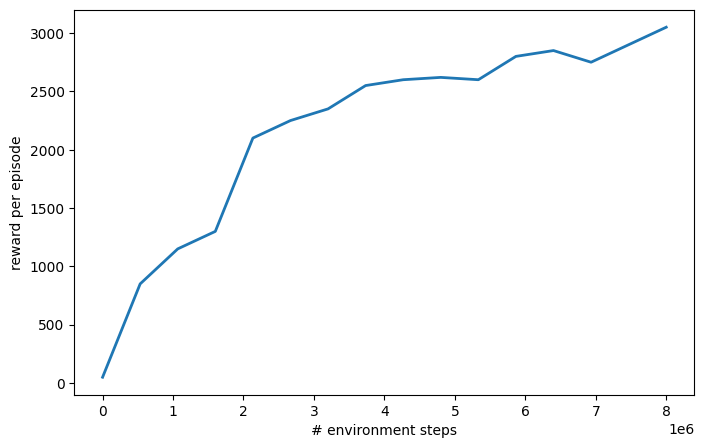

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
x = np.linspace(0, 8e6, 16)
y = [50, 850, 1150, 1300, 2100, 2250, 2350, 2550, 2600, 2620, 2600, 2800, 2850, 2750, 2900, 3050]

# 默认蓝色
blue_color = '#1f77b4'

# 绘图，不显示中间虚线（grid）
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(x, y, color=blue_color, linewidth=2)
ax.set_xlabel("# environment steps")
ax.set_ylabel("reward per episode")

# 显式保留四个边框
for spine in ax.spines.values():
    spine.set_visible(True)

# 关闭网格线
ax.grid(False)

# 保存图像
output_path = "/mnt/data/reward_vs_steps_no_grid.png"
plt.savefig(output_path, bbox_inches='tight', dpi=300)
plt.close()

output_path
